## Setup and Imports

In [22]:
import sys
sys.path.append("..")

import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_loader import load_train, load_test, load_submission_data
from src import config

#Disaply Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]= (12, 6)
%matplotlib inline

print('Setup completed')

Setup completed


## Load data

In [23]:
train_df = load_train()
test_df= load_test()
submission_df= load_submission_data()

print("Train shape:", train_df.shape)
print("Test Data:", test_df.shape)
print("Sample Submission shape:", submission_df.shape)

2026-05-17 15:02:41 | INFO     | data_logger     | Loading training data from c:\Users\goura\Data Science\Machine Learning\Practice\notebooks\..\data\raw\train.csv
2026-05-17 15:02:42 | INFO     | data_logger     | Loaded training data with shape (439140, 16)
2026-05-17 15:02:42 | INFO     | data_logger     | Loading test data from c:\Users\goura\Data Science\Machine Learning\Practice\notebooks\..\data\raw\test.csv
2026-05-17 15:02:42 | INFO     | data_logger     | Loaded test data with shape (188165, 15)
2026-05-17 15:02:42 | INFO     | data_logger     | Loading submission data from c:\Users\goura\Data Science\Machine Learning\Practice\notebooks\..\data\raw\sample_submission.csv
2026-05-17 15:02:42 | INFO     | data_logger     | Loaded submission data with shape (188165, 2)


Train shape: (439140, 16)
Test Data: (188165, 15)
Sample Submission shape: (188165, 2)


## First look at data

In [24]:
print("=" * 60)
print("First five rows of train data:")
print("="*60)
train_df.head()

First five rows of train data:


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [25]:
print("=" * 60)
print("First five rows of test data:")
print("=" * 60)
test_df.head()

First five rows of test data:


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


In [26]:
print("=" * 60)
print("SAMPLE SUBMISSION FORMAT")
print("=" * 60)
submission_df.head()

SAMPLE SUBMISSION FORMAT


,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0


## Data types & memory

In [27]:
print("=" * 60)
print("Train Data Info:")
print("=" * 60)
train_df.info()

Train Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Chang

In [28]:
# seperate numerical and categorical columns
numerical_cols= train_df.select_dtypes(include= ['int64', 'float64']).columns.tolist()
categorical_cols= train_df.select_dtypes(include= ['str']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)} : {numerical_cols}")
print(f"Categorical Columns: {len(categorical_cols)} : {categorical_cols}")

Numerical columns: 13 : ['id', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']
Categorical Columns: 3 : ['Driver', 'Compound', 'Race']


### Missing Values

In [29]:
def missing_values(df, name= "DataFrame"):
    """Generate missing values report for a DataFrame."""
    missing= df.isnull().sum()
    missing_percent= (missing / len(df))*100
    report= pd.DataFrame({
        "Missing Values": missing,
        "Missing %": missing_percent.round(2)
    })
    report= report[report["Missing Values"]>0].sort_values('Missing %', ascending= False)

    if report.empty:
        print(f"No missing values in {name}!")
    else:
        print(f"Missing Values Report for {name}:")
        print(report)
    return report

In [30]:
missing_train= missing_values(train_df, name= "Train Data")
missing_test= missing_values(test_df, name= "Test Data")

No missing values in Train Data!
No missing values in Test Data!


In [31]:
# Visualize missing values if any
if missing_train['Missing Values'].sum() > 0:
    plt.figure(figsize=(12, 4))
    sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Values heatmap - Train Data")
    plt.show()

if missing_test['Missing Values'].sum() > 0:
    plt.figure(figsize=(12, 4))
    sns.heatmap(test_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Values heatmap - Test Data")
    plt.show()


# No graphs as there are no missing values in the train and test data.

### Target Variable analysis

In [32]:
TARGET= config.TARGET_COL

print("="*60)
print(f"Target Column: {TARGET}")
print("="*60)
print(f"{train_df[TARGET].describe()}")
print(f"\nUnique values in target: {train_df[TARGET].nunique()}")
print(f"Data Type: {train_df[TARGET].dtype}")

Target Column: PitNextLap
count    439140.000000
mean          0.198982
std           0.399235
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: PitNextLap, dtype: float64

Unique values in target: 2
Data Type: float64


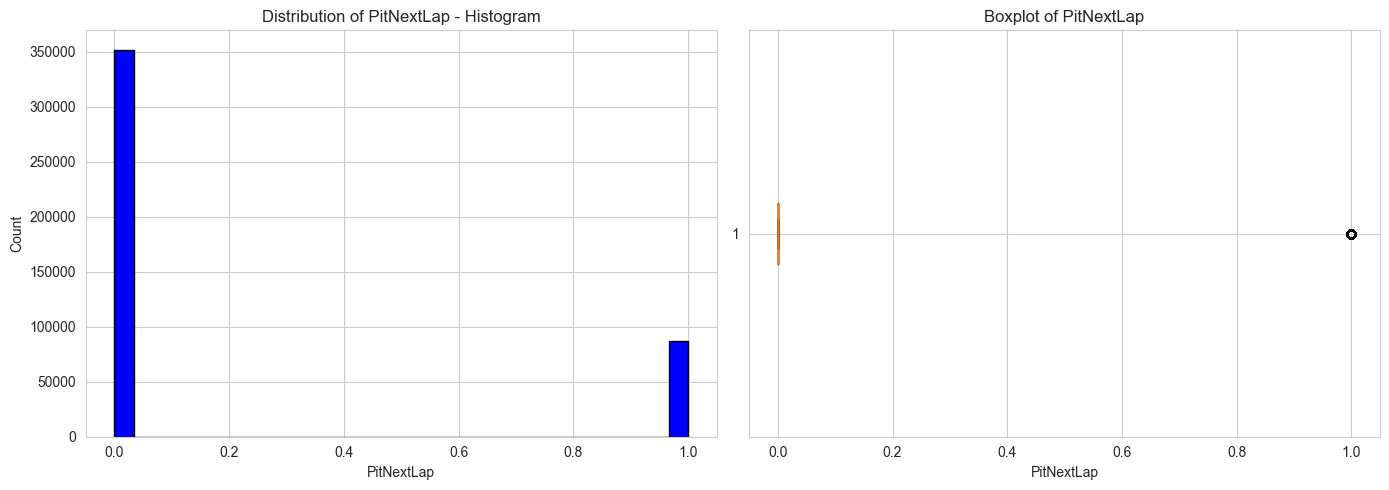

In [33]:
# Plot target distribution
fig, axes= plt.subplots(1, 2, figsize=(14, 5))

#Histogram
axes[0].hist(train_df[TARGET], bins= 30, color= 'blue', edgecolor= 'black')
axes[0].set_title(f"Distribution of {TARGET} - Histogram")
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel("Count")

# Boxplot
axes[1].boxplot(train_df[TARGET].dropna(), vert= False)
axes[1].set_title(f"Boxplot of {TARGET}")
axes[1].set_xlabel(TARGET) 

plt.tight_layout()
plt.show()

#### Highly imbalanced data
- approx 350000 rows of class 0
- approx 90000 rows of class 1

##### Box plot don't make sense as this is classification problem.

In [34]:
# class distribution
print('Class count (Training):')
print(train_df[TARGET].value_counts())
print('\nClass percentage %:')
print(train_df[TARGET].value_counts(normalize= True)*100)

Class count (Training):
PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

Class percentage %:
PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64


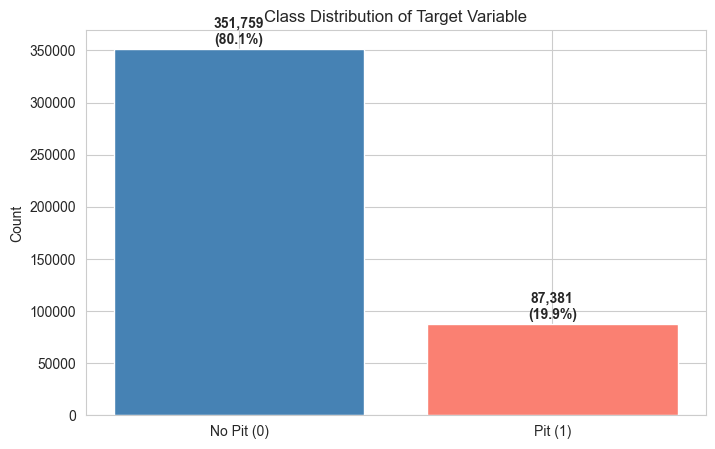

In [35]:
# Visualize properly for binary target

plt.figure(figsize= (8, 5))
counts= train_df[TARGET].value_counts()
plt.bar(["No Pit (0)", "Pit (1)"], counts.values, color= ['steelblue', 'salmon'])
for i, v in enumerate(counts.values):
    plt.text(i, v + 5000, f'{v:,}\n({v/len(train_df)*100:.1f}%)', ha='center', fontweight= 'bold') 
plt.title("Class Distribution of Target Variable")
plt.ylabel("Count")
plt.show()

### Class balance check

In [36]:
# Detailed class analysis

n_total= len(train_df)
n_class_0= (train_df[TARGET]== 0).sum()
n_class_1= (train_df[TARGET]== 1).sum()

print(f"Class Distribution:")
print(f" Class 0 (No Pit): {n_class_0:>7,} ({n_class_0/n_total*100:.2f}%)")
print(f" Class 1 (Pit): {n_class_1:>7,} ({n_class_1/n_total*100:.2f}%)")
print(f"\nImbalance Ratio: 1: {n_class_0/n_class_1:.2f}")
print(f" -> scale_pos_weight for XGBoost: {n_class_0/n_class_1:.2f}")

Class Distribution:
 Class 0 (No Pit): 351,759 (80.10%)
 Class 1 (Pit):  87,381 (19.90%)

Imbalance Ratio: 1: 4.03
 -> scale_pos_weight for XGBoost: 4.03


In [37]:
# Leaking info about PitStop and PitNextLap

print("Crosstab of PitStop vs PitNextLap:")
print(pd.crosstab(train_df['PitStop'], train_df[TARGET], ))

print("\nNormalized row%:")
print(pd.crosstab(train_df['PitStop'], train_df[TARGET], normalize= 'index')*100)


Crosstab of PitStop vs PitNextLap:
PitNextLap     0.0    1.0
PitStop                  
0           306798  72567
1            44961  14814

Normalized row%:
PitNextLap        0.0        1.0
PitStop                         
0           80.871456  19.128544
1           75.217064  24.782936


In [38]:
# Beautiful leakage analysis
print("=" * 60)
print("           DATA LEAKAGE CHECK: PitStop vs PitNextLap")
print("=" * 60)

# Raw counts
counts = pd.crosstab(train_df['PitStop'], train_df['PitNextLap'])
counts.columns = ['No Pit Next', 'Pit Next']
counts.index = ['No Pit Now', 'Pit Now']

# Percentages
pct = pd.crosstab(train_df['PitStop'], train_df['PitNextLap'], normalize='index') * 100
pct.columns = ['No Pit Next (%)', 'Pit Next (%)']
pct.index = ['No Pit Now', 'Pit Now']

print("\n📊 RAW COUNTS")
print("-" * 60)
print(counts.to_string())

print("\n📈 PERCENTAGE (Row-wise)")
print("-" * 60)
print(pct.round(2).to_string())

# Calculate lift
baseline = train_df['PitNextLap'].mean() * 100
lift_no_pit = pct.iloc[0]['Pit Next (%)'] - baseline
lift_pit    = pct.iloc[1]['Pit Next (%)'] - baseline

print("\n🎯 LEAKAGE ANALYSIS")
print("-" * 60)
print(f"Baseline pit rate (overall):          {baseline:>6.2f}%")
print(f"Pit rate when PitStop=0:              {pct.iloc[0]['Pit Next (%)']:>6.2f}%  (lift: {lift_no_pit:+.2f}%)")
print(f"Pit rate when PitStop=1:              {pct.iloc[1]['Pit Next (%)']:>6.2f}%  (lift: {lift_pit:+.2f}%)")

# Verdict
max_lift = max(abs(lift_no_pit), abs(lift_pit))
print("\n" + "=" * 60)
if max_lift > 50:
    print("🚨 VERDICT: SEVERE LEAKAGE — DROP THIS COLUMN!")
elif max_lift > 20:
    print("⚠️  VERDICT: SUSPICIOUS — INVESTIGATE FURTHER")
else:
    print("✅ VERDICT: NO LEAKAGE — Safe to use")
print("=" * 60)

           DATA LEAKAGE CHECK: PitStop vs PitNextLap

📊 RAW COUNTS
------------------------------------------------------------
            No Pit Next  Pit Next
No Pit Now       306798     72567
Pit Now           44961     14814

📈 PERCENTAGE (Row-wise)
------------------------------------------------------------
            No Pit Next (%)  Pit Next (%)
No Pit Now            80.87         19.13
Pit Now               75.22         24.78

🎯 LEAKAGE ANALYSIS
------------------------------------------------------------
Baseline pit rate (overall):           19.90%
Pit rate when PitStop=0:               19.13%  (lift: -0.77%)
Pit rate when PitStop=1:               24.78%  (lift: +4.88%)

✅ VERDICT: NO LEAKAGE — Safe to use


## 🔍 Data Leakage check - Results

### Pit Stop Column
| Condition | Pit Rate | Lift vs Baseline |
|-----------|----------|------------------|
| Baseline(Overall) | 19.90% | - |
| PitStop =  0 | 19.13% | -0.77% |
| PitStop = 1 | 24.78% | +4.88% |

**Verdict:** ✅ Safe to use
- Lift is below 20% threashold
- Provides usefull signal, not leakage
- keep in future set

In [39]:
print("="*60)
print("Categorical Columns Analysis:")
print("="*60)

for col in categorical_cols:
    print(f"\n🔤 Column: {col}")
    print("-" * 60)
    print(f"Unique values: {train_df[col].nunique()}")
    print(f"Most common: {train_df[col].mode()[0]}")
    print(f"\nTop 10 frequencies:")
    print(train_df[col].value_counts().head(10))
print("="*60)

Categorical Columns Analysis:

🔤 Column: Driver
------------------------------------------------------------
Unique values: 887
Most common: MAS

Top 10 frequencies:
Driver
MAS    1682
RAI    1669
BAR    1656
BUT    1655
FIS    1651
KUB    1650
TRU    1613
KOV    1607
HEI    1587
SUT    1579
Name: count, dtype: int64

🔤 Column: Compound
------------------------------------------------------------
Unique values: 5
Most common: MEDIUM

Top 10 frequencies:
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64

🔤 Column: Race
------------------------------------------------------------
Unique values: 26
Most common: Dutch Grand Prix

Top 10 frequencies:
Race
Dutch Grand Prix          24462
Mexico City Grand Prix    23672
Pre-Season Testing        22492
Hungarian Grand Prix      22481
Monaco Grand Prix         21539
Canadian Grand Prix       21416
Austrian Grand Prix       21223
Spanish Grand Pri

In [43]:
print("="*60)
print("Train Vs Test Categorical Comparison:")
print("="*60)

for col in categorical_cols:
    print(f"\n🔤 {col}")
    print("-"*60)
    train_counts= set(train_df[col].unique())
    test_counts= set(test_df[col].unique())
    only_in_test= test_counts - train_counts
    only_in_train= train_counts - test_counts
    common= train_counts & test_counts
    print(f"Train Unique Categories: {len(train_counts)}")
    print(f"Test Unique Categories: {len(test_counts)}")
    print(f"Common categories: {len(common)}")
    print(f"Only in Test (Unseen): {len(only_in_test)}")
    print(f"Only in Train: {len(only_in_train)}")
    if only_in_test:
        print(f"\n⚠️ Warning: Test has unseen categories: {only_in_test}")
    else:
        print(f"\n✅ All test categories are seen in train.")
print("="*60)

Train Vs Test Categorical Comparison:

🔤 Driver
------------------------------------------------------------
Train Unique Categories: 887
Test Unique Categories: 801
Common categories: 801
Only in Test (Unseen): 0
Only in Train: 86

✅ All test categories are seen in train.

🔤 Compound
------------------------------------------------------------
Train Unique Categories: 5
Test Unique Categories: 5
Common categories: 5
Only in Test (Unseen): 0
Only in Train: 0

✅ All test categories are seen in train.

🔤 Race
------------------------------------------------------------
Train Unique Categories: 26
Test Unique Categories: 26
Common categories: 26
Only in Test (Unseen): 0
Only in Train: 0

✅ All test categories are seen in train.
